In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import timm
from tqdm import tqdm
import time
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
import seaborn as sns

Mounted at /content/drive


In [4]:
BASE_PATH     = "/content/drive/MyDrive/FinalProject/new data"
METADATA_PATH = os.path.join(BASE_PATH, "HAM10000_metadata.csv")
IMAGES_PATH   = os.path.join(BASE_PATH, "images")
MODEL_DIR     = "/content/drive/MyDrive/FinalProject/models"
BEST_MODEL_V4 = os.path.join(MODEL_DIR, "best_model_v4.pth")

os.makedirs(MODEL_DIR, exist_ok=True)

In [5]:
df = pd.read_csv(METADATA_PATH)
df = df.dropna(subset=["image_id"]).reset_index(drop=True)

suspicious_map = {
    "mel": 1, "bcc": 1, "akiec": 1,
    "nv": 0,  "bkl": 0, "df": 0, "vasc": 0
}
df["suspicious"] = df["dx"].map(suspicious_map)

train_df = pd.read_csv("/content/drive/MyDrive/FinalProject/splits/train_df.csv")
val_df   = pd.read_csv("/content/drive/MyDrive/FinalProject/splits/val_df.csv")
test_df  = pd.read_csv("/content/drive/MyDrive/FinalProject/splits/test_df.csv")

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

Train: 7010 | Val: 1502 | Test: 1503


In [6]:
train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(300, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

val_transforms = transforms.Compose([
    transforms.Resize((300, 300)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

In [7]:
class SkinDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.img_dir, row["image_id"] + ".jpg")
        try:
            img = Image.open(img_path).convert("RGB")
        except:
            img = Image.fromarray(np.zeros((300,300,3), dtype=np.uint8))
        label = torch.tensor(int(row["suspicious"]), dtype=torch.long)
        if self.transform:
            img = self.transform(img)
        return img, label, row["image_id"]

train_dataset = SkinDataset(train_df, IMAGES_PATH, train_transforms)
val_dataset   = SkinDataset(val_df,   IMAGES_PATH, val_transforms)
test_dataset  = SkinDataset(test_df,  IMAGES_PATH, val_transforms)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False, num_workers=2)

print("Loaders ready!")

Loaders ready!


In [8]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

model = timm.create_model("efficientnet_b3", pretrained=True, num_classes=2).to(device)

# Weighted Loss
class_weights = torch.tensor([1.0, 3.0], device=device)
criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)


Device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/49.3M [00:00<?, ?B/s]

In [9]:
# TRAINING LOOP - V4

EPOCHS = 20

history_v4 = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": []
}

best_val_loss_v4 = float("inf")

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    start_time = time.time()

    # TRAIN
    model.train()
    train_loss, train_correct, train_total = 0, 0, 0

    pbar = tqdm(train_loader, desc="Training", leave=False)

    for images, labels, _ in pbar:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        preds = torch.argmax(outputs, dim=1)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

        pbar.set_postfix({
            "loss": f"{loss.item():.4f}",
            "acc": f"{train_correct/train_total:.4f}"
        })

    scheduler.step()

    # VALIDATION
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for images, labels, _ in tqdm(val_loader, desc="Validating", leave=False):
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    epoch_time = time.time() - start_time

    tl = train_loss / len(train_loader)
    vl = val_loss / len(val_loader)
    ta = train_correct / train_total
    va = val_correct / val_total

    history_v4["train_loss"].append(tl)
    history_v4["val_loss"].append(vl)
    history_v4["train_acc"].append(ta)
    history_v4["val_acc"].append(va)

    if vl < best_val_loss_v4:
        best_val_loss_v4 = vl
        torch.save(model.state_dict(), BEST_MODEL_V4)
        print("Saved best_model_v4.pth")

    print(f"Train Loss: {tl:.4f} | Train Acc: {ta:.4f}")
    print(f"Val   Loss: {vl:.4f} | Val   Acc: {va:.4f}")
    print(f"Time: {epoch_time:.2f}s | LR: {scheduler.get_last_lr()[0]:.6f}")
    print("-" * 50)


Epoch 1/20


Saved best_model_v4.pth
Train Loss: 0.8483 | Train Acc: 0.7618
Val   Loss: 0.6322 | Val   Acc: 0.8196
Time: 3566.81s | LR: 0.000099
--------------------------------------------------

Epoch 2/20


Train Loss: 0.4722 | Train Acc: 0.8243
Val   Loss: 4.9257 | Val   Acc: 0.8329
Time: 71.22s | LR: 0.000098
--------------------------------------------------

Epoch 3/20


Train Loss: 0.3488 | Train Acc: 0.8573
Val   Loss: 1.2434 | Val   Acc: 0.8522
Time: 71.68s | LR: 0.000095
--------------------------------------------------

Epoch 4/20


Saved best_model_v4.pth
Train Loss: 0.2915 | Train Acc: 0.8745
Val   Loss: 0.3833 | Val   Acc: 0.8562
Time: 71.23s | LR: 0.000090
--------------------------------------------------

Epoch 5/20


...

Train Loss: 0.0417 | Train Acc: 0.9846
Val   Loss: 0.5420 | Val   Acc: 0.9035
Time: 72.10s | LR: 0.000010
--------------------------------------------------

Epoch 17/20


Train Loss: 0.0393 | Train Acc: 0.9884
Val   Loss: 0.5774 | Val   Acc: 0.9101
Time: 72.27s | LR: 0.000005
--------------------------------------------------

Epoch 18/20


Train Loss: 0.0317 | Train Acc: 0.9897
Val   Loss: 0.5393 | Val   Acc: 0.9101
Time: 73.09s | LR: 0.000002
--------------------------------------------------

Epoch 19/20


Train Loss: 0.0301 | Train Acc: 0.9909
Val   Loss: 0.5151 | Val   Acc: 0.9134
Time: 71.58s | LR: 0.000001
--------------------------------------------------

Epoch 20/20


Train Loss: 0.0287 | Train Acc: 0.9930
Val   Loss: 0.5394 | Val   Acc: 0.9061
Time: 72.78s | LR: 0.000000
--------------------------------------------------


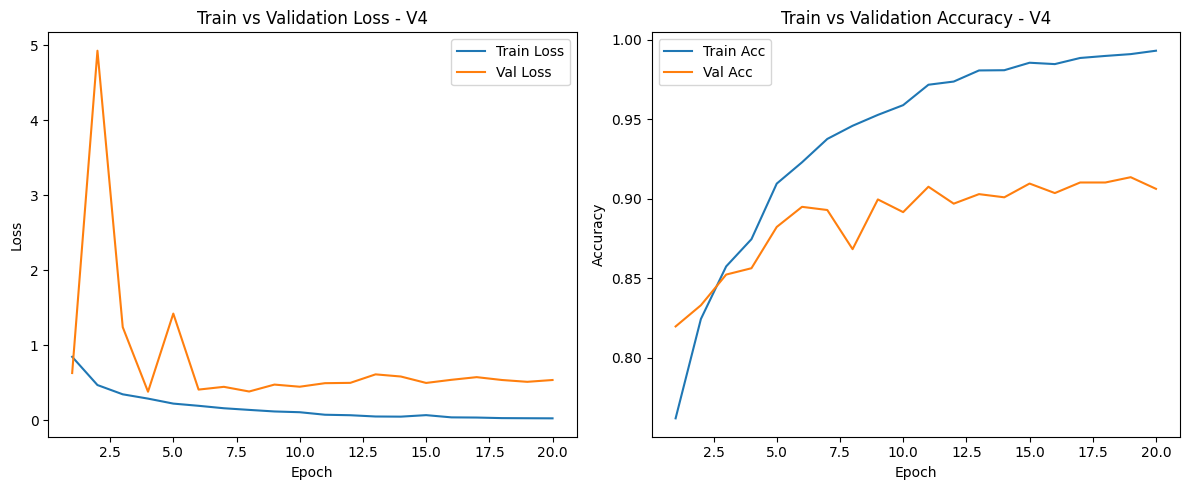

In [11]:
epochs = range(1, EPOCHS + 1)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(epochs, history_v4["train_loss"], label="Train Loss")
plt.plot(epochs, history_v4["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train vs Validation Loss - V4")
plt.legend()

plt.subplot(1,2,2)
plt.plot(epochs, history_v4["train_acc"], label="Train Acc")
plt.plot(epochs, history_v4["val_acc"], label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Train vs Validation Accuracy - V4")
plt.legend()

plt.tight_layout()
plt.show()

In [12]:
model.load_state_dict(torch.load(BEST_MODEL_V4, map_location=device))
model.eval()

all_labels, all_preds, all_probs = [], [], []

with torch.no_grad():
    for images, labels, _ in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)[:, 1]
        preds = torch.argmax(outputs, dim=1)
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

print(f"\nTest Accuracy: {accuracy_score(all_labels, all_preds):.4f}")
print(classification_report(all_labels, all_preds, target_names=["Not Suspicious", "Suspicious"]))


Test Accuracy: 0.8510
                precision    recall  f1-score   support

Not Suspicious       0.95      0.86      0.90      1210
    Suspicious       0.58      0.81      0.68       293

      accuracy                           0.85      1503
     macro avg       0.77      0.84      0.79      1503
  weighted avg       0.88      0.85      0.86      1503

